# Jour 1 — Exploration de l'environnement thermique

Ce notebook explore le comportement de `BatteryThermalEnv` :
- épisode avec action aléatoire
- épisode avec refroidissement constant
- visualisation température / SoC / action / récompense

In [1]:
import sys
sys.path.insert(0, '..')  # accès aux modules depuis le dossier notebooks/

import numpy as np
import matplotlib.pyplot as plt
from envs.battery_thermal_env import BatteryThermalEnv
from config import DEFAULT_CONFIG

## 1. Épisode avec politique aléatoire

In [1]:
env = BatteryThermalEnv()
obs, info = env.reset(seed=42)

done = False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

print(f'Épisode terminé après {env._step_count} steps')
print(f'Récompense cumulée : {sum(env.history["reward"]):.2f}')

NameError: name 'BatteryThermalEnv' is not defined

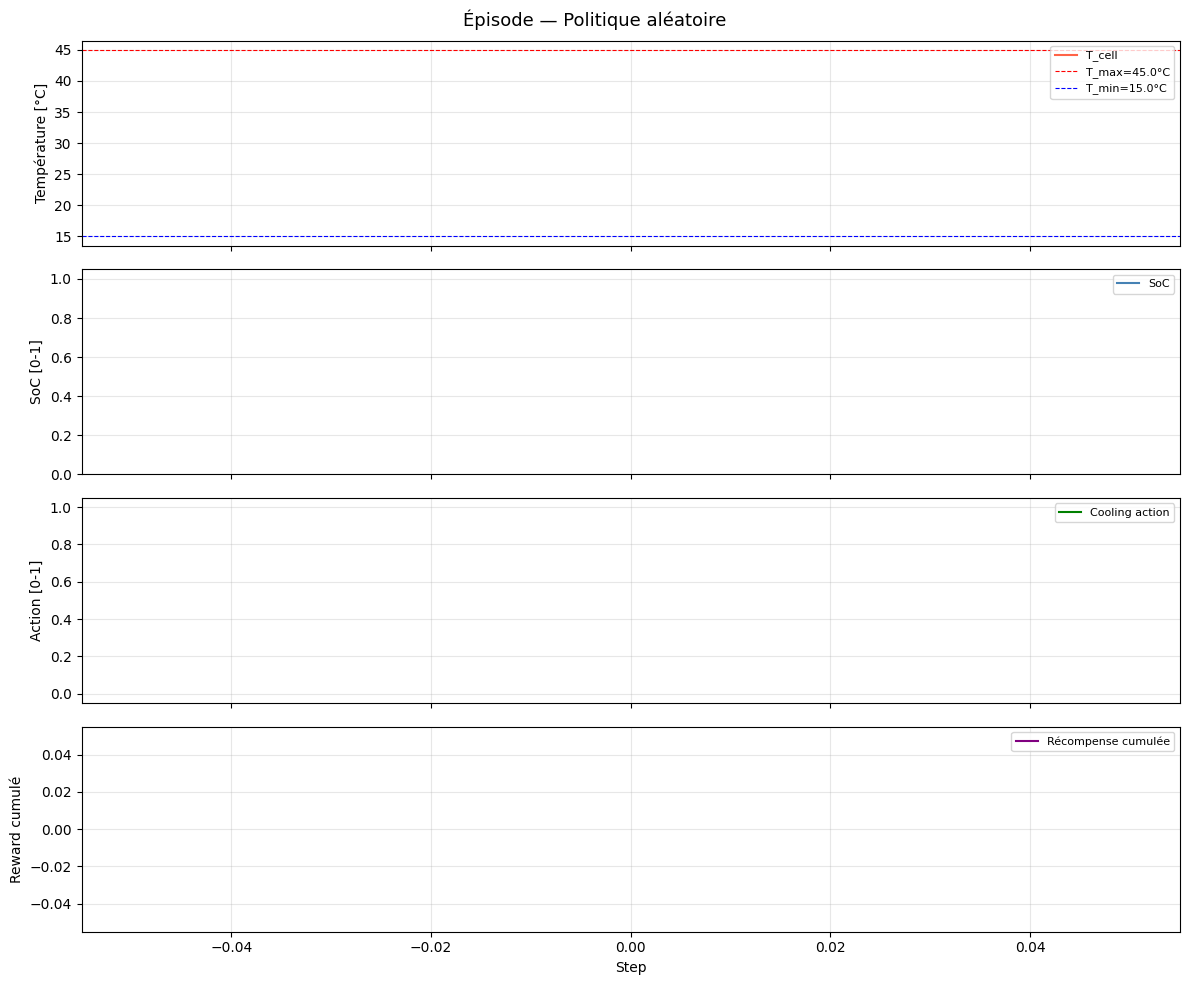

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
steps = range(len(env.history['T']))

# Température
axes[0].plot(steps, env.history['T'], color='tomato', label='T_cell')
axes[0].axhline(env.tc.T_safe_max, color='red',    linestyle='--', linewidth=0.8, label=f'T_max={env.tc.T_safe_max}°C')
axes[0].axhline(env.tc.T_safe_min, color='blue',   linestyle='--', linewidth=0.8, label=f'T_min={env.tc.T_safe_min}°C')
axes[0].set_ylabel('Température [°C]')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(alpha=0.3)

# SoC
axes[1].plot(steps, env.history['SoC'], color='steelblue', label='SoC')
axes[1].set_ylabel('SoC [0-1]')
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(alpha=0.3)

# Action (refroidissement)
axes[2].plot(steps, env.history['action'], color='green', label='Cooling action')
axes[2].set_ylabel('Action [0-1]')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(alpha=0.3)

# Récompense cumulée
cumreward = np.cumsum(env.history['reward'])
axes[3].plot(steps, cumreward, color='purple', label='Récompense cumulée')
axes[3].set_ylabel('Reward cumulé')
axes[3].set_xlabel('Step')
axes[3].legend(loc='upper right', fontsize=8)
axes[3].grid(alpha=0.3)

plt.suptitle('Épisode — Politique aléatoire', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Comparaison : sans refroidissement vs. refroidissement max

In [ ]:
results = {}

for label, cool_val in [('Aucun refroidissement (a=0)', 0.0),
                         ('Refroidissement max (a=1)', 1.0)]:
    env = BatteryThermalEnv()
    env.reset(seed=7)
    done = False
    while not done:
        action = np.array([cool_val], dtype=np.float32)
        _, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    results[label] = dict(env.history)
    print(f'{label} | steps={env._step_count} | reward={sum(env.history["reward"]):.2f}')

fig, ax = plt.subplots(figsize=(12, 4))
for label, hist in results.items():
    ax.plot(hist['T'], label=label)
ax.axhline(env.tc.T_safe_max, color='red',  linestyle='--', linewidth=0.8)
ax.axhline(env.tc.T_safe_min, color='blue', linestyle='--', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Température [°C]')
ax.set_title('Impact du refroidissement sur la température')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Vérification des espaces observation / action

In [ ]:
env = BatteryThermalEnv()
print('Observation space :', env.observation_space)
print('Action space      :', env.action_space)
print()

# Vérification que les observations restent dans [-1, 1] sur 200 resets
violations = 0
for seed in range(200):
    obs, _ = env.reset(seed=seed)
    if not env.observation_space.contains(obs):
        violations += 1

print(f'Violations de bornes sur 200 resets : {violations}')